# 04 · Grouped misconception chains, conceptual and procedural

Runs the notebook 03 analysis on two grouped chains. Each group's cells are the priority merge of its member families, P over A over N, the group latent reading "any member belief is active." Conceptual groups comprehension, relevance, and principles, procedural groups wrong-operation and steps, the mapping is the `GROUPS` constant in `misconception_chains_grouped.py`, and the documented compromise of the merge is that a lone member's A becomes the whole group's A.

**No number here is comparable to notebook 03's tables.** The merged cells are a different label population, conceptual's informative rate is roughly the union of three families'. The only fair cross-architecture comparison is section 6, both architectures scored on the same merged-cell task.

**Predictions this run can falsify:**

- The unconstrained conceptual chain degenerates comprehension-style, standing disposition, TNR collapse, because the merged stream inherits comprehension's P density, which would show the pathology tracks evidence structure, not family identity.
- Grouped fitted kill rates land inside the family band of 0.01 to 0.09, conceptual's near comprehension's 0.032 since comprehension dominates the merge.
- The ceiling's cost-benefit may genuinely differ here, the conceptual column is the densest P-stream in the project, where the fortress bites hardest.

Selection criterion as in notebook 03, AUC within this table, ties on the TPR and TNR balance.

## 1. Setup

In [1]:
import pandas as pd
from scripts.load_data import load_paper_filtered_data
from scripts.chain import Chain, TriggerChain
from scripts.misconception_chains import MisconceptionChains
from scripts.misconception_chains_grouped import GroupedChains, GROUPS

train_df = load_paper_filtered_data("data/mathdial_train.csv")
test_df = load_paper_filtered_data("data/mathdial_test.csv")
GROUP_NAMES = list(GROUPS)

## 2. Configurations

The mechanism ladder from notebook 03, pruned to the rows whose answers grouping could genuinely change. The dial brackets, kill sharpness, snap strength, prior nudges, resolved into within-noise ties there and are not rerun.

**unconstrained** `Chain()`

- Pins, none. The degeneracy check, does the merged conceptual stream reproduce the perpetual-risk fit.

**start low** `pi=0.05, onset=1e-6, pP_i=0.05`

- Free, `resolve`, `pP_a`. The emission-escape check, does EM again file A cells as active-state noise with resolve collapsing.

**sharp kill** `pi=0.05, onset=1e-6, pP_i=0.05, pP_a=0.97`

- Free, `resolve`. The recovered-kill-rate check, the fitted resolve is the data-estimated death rate of a grouped belief.

**strong snap** `pi=0.05, onset=1e-6, pP_i=0.02, pP_a=0.97`

- Free, `resolve`. The chain of record from the family sweep, the presumptive grouped pick.

**strong snap + ceiling** `adds ceiling=0.95`

- Re-tested rather than carried over as rejected, the fortress bites hardest in dense P-runs and the merged conceptual column is the densest in the project.

## 3. Fit all configurations

In [2]:
CONFIGS = {
    "unconstrained":         (Chain, {}),
    "start low":             (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05}),
    "sharp kill":            (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.97}),
    "strong snap":           (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.02, "pP_a": 0.97}),
    "strong snap + ceiling": (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.02,
                                             "pP_a": 0.97, "ceiling": 0.95}),
}

models = {}
for name, (chain_class, kwargs) in CONFIGS.items():
    model = GroupedChains(train_df, test_df, chain_class=chain_class,
                         chain_kwargs=kwargs)
    model.run()
    models[name] = model
    print(f"fitted {name}")

fitted unconstrained
fitted start low
fitted sharp kill
fitted strong snap
fitted strong snap + ceiling


## 4. Comparison table

In [3]:
comparison = pd.concat(
    [models[name].summary().assign(config=name) for name in CONFIGS])
comparison = comparison.set_index(["chain", "config"]).sort_index()
comparison[["pi", "onset", "resolve", "pP_i", "pP_a",
            "accuracy", "tpr", "tnr", "auc", "f1", "informative_cells"]]

pi   onset  resolve    pP_i    pP_a  \
chain      config                                                           
conceptual sharp kill             0.0500  0.0000   0.0241  0.0500  0.9700   
           start low              0.0500  0.0000   0.0073  0.0500  0.9247   
           strong snap            0.0500  0.0000   0.0348  0.0200  0.9700   
           strong snap + ceiling  0.0500  0.0000   0.0080  0.0200  0.9700   
           unconstrained          0.9077  0.4222   0.0922  0.0463  0.9441   
procedural sharp kill             0.0500  0.0000   0.0717  0.0500  0.9700   
           start low              0.0500  0.0000   0.0201  0.0500  0.8551   
           strong snap            0.0500  0.0000   0.0870  0.0200  0.9700   
           strong snap + ceiling  0.0500  0.0000   0.0639  0.0200  0.9700   
           unconstrained          0.4209  0.0490   0.0994  0.0625  0.8498   

                                  accuracy     tpr     tnr     auc      f1  \
chain      config                                                            
conceptual sharp kill               0.5949  0.6077  0.5150  0.5888  0.7209   
           start low                0.4871  0.4665  0.6150  0.5743  0.6103   
           strong snap              0.6324  0.6683  0.4100  0.5801  0.7579   
           strong snap + ceiling    0.6317  0.6675  0.4100  0.5686  0.7573   
           unconstrained            0.8617  0.9976  0.0200  0.6099  0.9255   
procedural sharp kill               0.5944  0.3474  0.8805  0.7147  0.4790   
           start low                0.5998  0.3910  0.8418  0.7217  0.5119   
           strong snap              0.6739  0.5610  0.8047  0.7250  0.6487   
           strong snap + ceiling    0.6763  0.5698  0.7997  0.7220  0.6539   
           unconstrained            0.6880  0.6105  0.7778  0.7294  0.6774   

                                  informative_cells  
chain      config                                    
conceptual sharp kill                          1439  
           start low                           1439  
           strong snap                         1439  
           strong snap + ceiling               1439  
           unconstrained                       1439  
procedural sharp kill                          1282  
           start low                           1282  
           strong snap                         1282  
           strong snap + ceiling               1282  
           unconstrained                       1282

## 5. AUC by group, the selection view

In [4]:
comparison.reset_index().pivot(index="config", columns="chain",
                                values="auc").round(4)

chain,conceptual,procedural
config,,
sharp kill,0.5888,0.7147
start low,0.5743,0.7217
strong snap,0.5801,0.7250
strong snap + ceiling,0.5686,0.7220
unconstrained,0.6099,0.7294


## 6. The noisy-OR bridge, grouping before versus after fitting

The one fair cross-architecture comparison, both architectures scored on the identical merged-cell task. The grouped chains predict natively. The five family chains, fitted here under the chain-of-record configuration, predict each member's evidence probability, and the bridge combines them as one minus the product of one minus each member's q, the probability that at least one member exhibits. If the bridge matches or beats the native grouped chains, merging cells before fitting buys nothing over merging predictions after.

In [5]:
import numpy as np
from scripts.chain import extract_sequences

family_model = MisconceptionChains(
    train_df, test_df, chain_class=TriggerChain,
    chain_kwargs={"pi": 0.05, "onset": 1e-6, "pP_i": 0.02, "pP_a": 0.97})
family_model.run()

grouped = models["strong snap"]
grouped_test = grouped.reformat(test_df)
rows = []
for group, members in GROUPS.items():
    merged = extract_sequences(grouped_test, group)
    member_seqs = {m: extract_sequences(test_df, m) for m in members}
    labels, native, bridge = [], [], []
    for d, symbols in merged.items():
        q_native = getattr(grouped, group).predict_evidence(symbols)
        q_members = [getattr(family_model, m).predict_evidence(member_seqs[m][d])
                     for m in members]
        q_bridge = 1 - np.prod([1 - q for q in q_members], axis=0)
        for t, s in enumerate(symbols):
            if s:
                labels.append(1 if s == 2 else 0)
                native.append(q_native[t])
                bridge.append(q_bridge[t])
    labels = np.array(labels)
    for name, scores in [("grouped native", np.array(native)),
                         ("family bridge", np.array(bridge))]:
        ranks = pd.Series(scores).rank().to_numpy()
        pos, neg = labels.sum(), (labels == 0).sum()
        predicted = scores >= 0.5
        tp = (predicted & (labels == 1)).sum()
        rows.append({
            "group": group, "architecture": name,
            "auc": round(float((ranks[labels == 1].sum() - pos * (pos + 1) / 2)
                               / (pos * neg)), 4),
            "tpr": round(float(predicted[labels == 1].mean()), 4),
            "tnr": round(float((~predicted[labels == 0]).mean()), 4),
            "f1": round(float(2 * tp / max(2 * tp + (predicted & (labels == 0)).sum()
                                           + (~predicted & (labels == 1)).sum(), 1)), 4),
            "cells": int(len(labels)),
        })
pd.DataFrame(rows).set_index(["group", "architecture"])

auc     tpr     tnr      f1  cells
group      architecture                                         
conceptual grouped native  0.5801  0.6683  0.4100  0.7579   1439
           family bridge   0.5777  0.6764  0.3950  0.7625   1439
procedural grouped native  0.7250  0.5610  0.8047  0.6487   1282
           family bridge   0.7157  0.5770  0.7980  0.6589   1282

## 7. Scenario response curves

As in notebook 03, controlled sequences against the fitted chains, here for one group. Change GROUP to inspect the other.

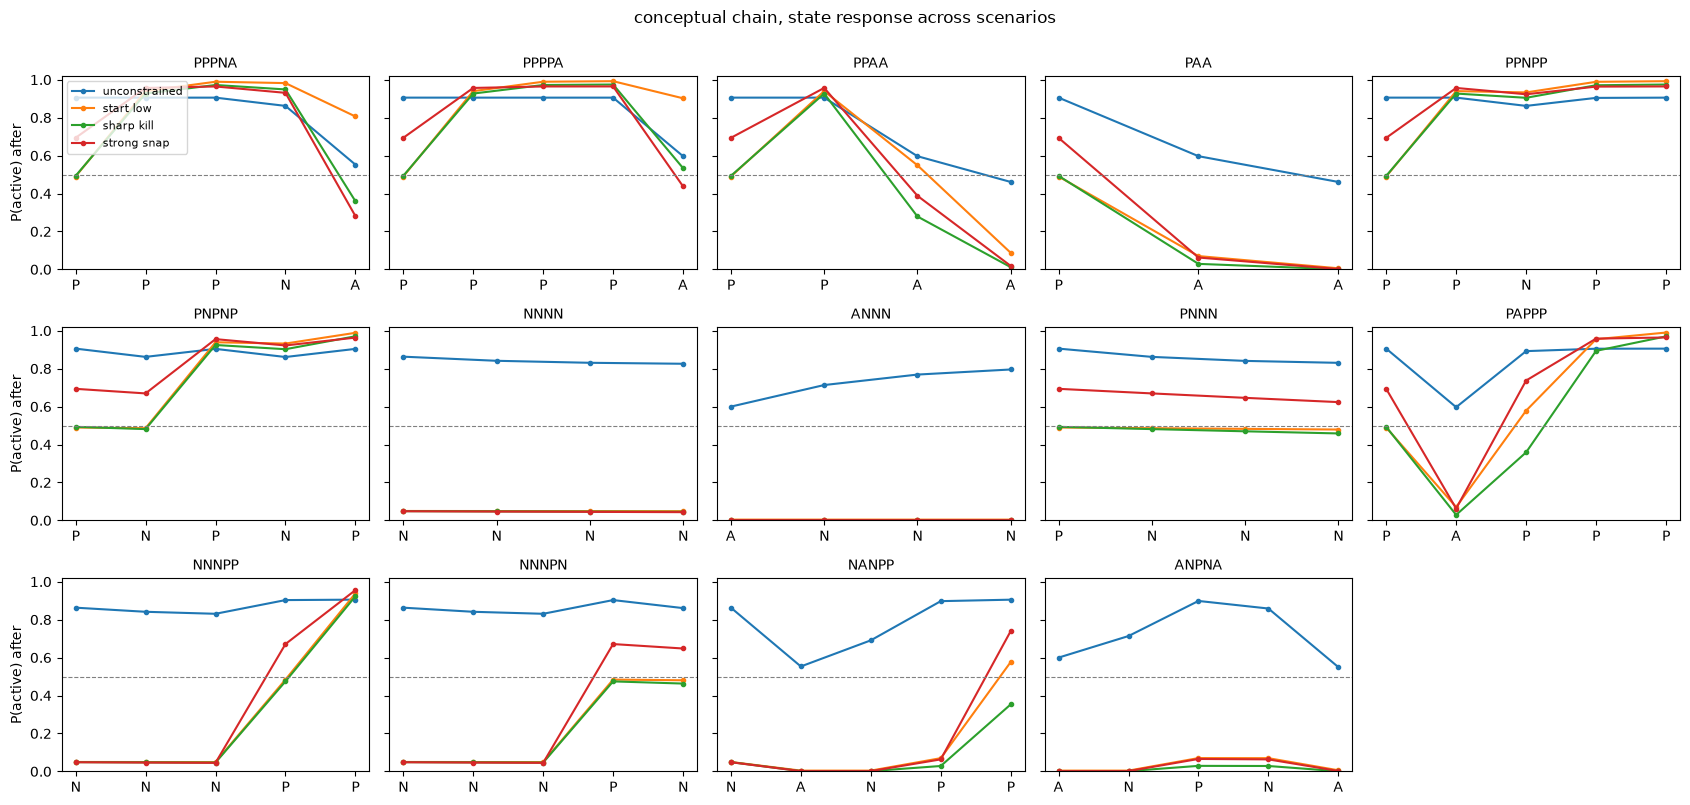

In [6]:
import matplotlib.pyplot as plt

GROUP = "conceptual"
VALUE = "state"  # "state" or "evidence"
SHOW_SCENARIOS = ["unconstrained", "start low", "sharp kill", "strong snap"]
SCENARIOS = ["PPPNA", "PPPPA", "PPAA", "PAA", "PPNPP", "PNPNP", "NNNN",
             "ANNN", "PNNN", "PAPPP", "NNNPP", "NNNPN", "NANPP", "ANPNA"]
CODE = {"N": 0, "A": 1, "P": 2}

fig, axes = plt.subplots(3, 5, figsize=(17, 8), sharey=True)
for ax, scenario in zip(axes.flat, SCENARIOS):
    symbols = np.array([CODE[s] for s in scenario])
    for name in SHOW_SCENARIOS:
        chain = getattr(models[name], GROUP)
        after = chain.predict_state(np.append(symbols, 0))[1:]
        track = after if VALUE == "state" else             after * chain.pP_a + (1 - after) * chain.pP_i
        ax.plot(range(len(scenario)), track, marker="o", markersize=3, label=name)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(len(scenario)))
    ax.set_xticklabels(list(scenario))
    ax.set_title(scenario, fontsize=10)
    ax.set_ylim(0, 1.02)
for ax in axes.flat[len(SCENARIOS):]:
    ax.set_visible(False)
for row in range(3):
    axes[row, 0].set_ylabel("P(active) after" if VALUE == "state"
                            else "P(next cell is P)")
axes.flat[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"{GROUP} chain, {VALUE} response across scenarios", y=1.0)
plt.tight_layout()
plt.show()

## 8. Notes

- The grouped chains live as attributes, `models["strong snap"].conceptual` and `.procedural`, and `predict_states` returns per-dialogue arrays of shape (units, 2) for the gate ablation.
- The alternative grouping, wrong-operation filed under conceptual on the transformation-stage reading, is a three-line subclass overriding `GROUPS`, noted rather than run since it leaves procedural as steps alone.
- Whether grouping earns a seat in the gate ablation is decided by section 6 here and by the gate itself, not by comparing this table to notebook 03.